# Lecture 5: Classification and Maximum Likelihood Estimation

### Applied Machine Learning

__Kyra Gan__<br>Cornell Tech

# Multi-Class Classification
Let's load a fully multiclass version of the Iris dataset.

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

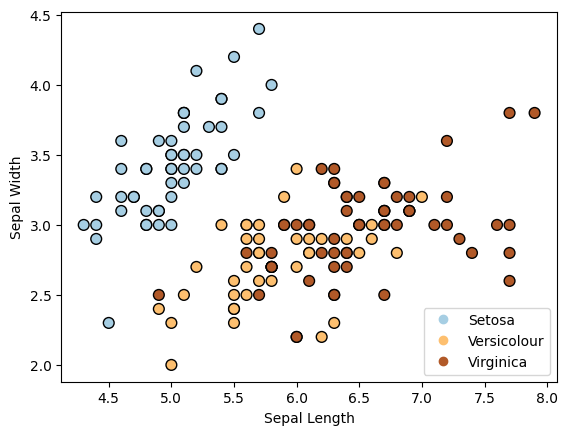

In [1]:
# https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the Iris dataset
iris = datasets.load_iris(as_frame=True)

print(iris.DESCR)

iris_X, iris_y = iris.data, iris.target
pd.concat([iris_X, iris_y], axis=1).head()

# Plot also the training points
p1 = plt.scatter(iris_X.iloc[:, 0], iris_X.iloc[:, 1], c=iris_y,
            edgecolor='k', s=60, cmap=plt.cm.Paired)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(handles=p1.legend_elements()[0], labels=['Setosa', 'Versicolour', 'Virginica'], loc='lower right')

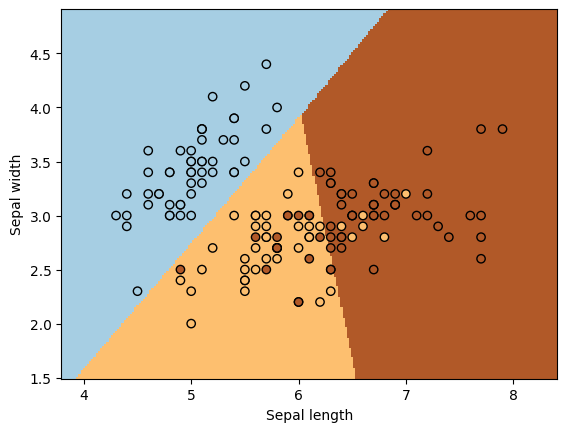

In [2]:
# https://scikit-learn.org/stable/auto_examples/linear_model/plot_iris_logistic.html
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=1e5, multi_class='multinomial')

X = iris_X.to_numpy()[:,:2]
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, .02), np.arange(y_min, y_max, .02))

# Create an instance of Softmax and fit the data.
logreg.fit(X, iris_y)
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=iris_y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

plt.show()

# Classification

When classification labels take $K=2$ values, we perform __binary classification__.

An example of a classification task is the Iris flower dataset.

In [3]:
# import standard machine learning libraries
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split

iris = datasets.load_iris() # load the Iris dataset
X, y = iris.data[:120, :2], iris.target[:120] # create imbalanced classes and only use first 2 features
X, X_holdout, y, y_holdout = train_test_split(X, y, test_size=50, random_state=0)

We may visualize this dataset in 2D.

Text(0.5, 0, 'Sepal length (cm)')

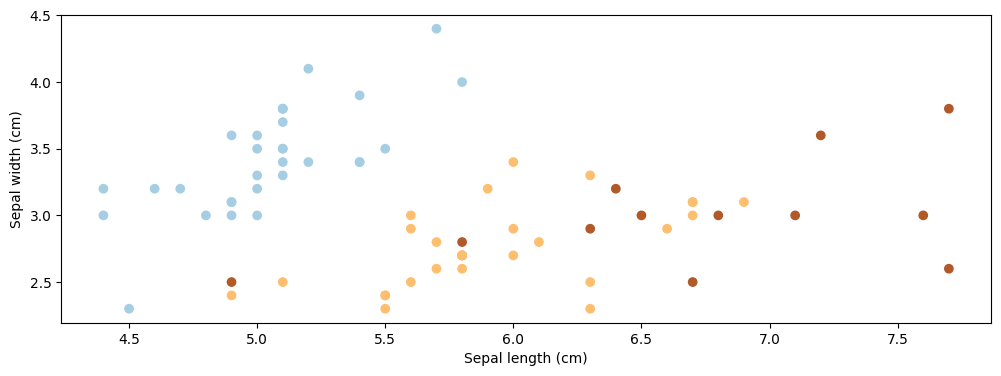

In [4]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [12, 4]

# Visualize the Iris flower dataset
setosa_flowers = (iris.target == 0)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Paired)
plt.ylabel("Sepal width (cm)")
plt.xlabel("Sepal length (cm)")

# Review: Machine Learning Models

A machine learning model is a function
$$ f : \mathcal{X} \to \mathcal{Y} $$
that maps inputs $x \in \mathcal{X}$ to targets $y \in \mathcal{Y}$.

Below, we fit a Softmax model to the Iris dataset.

In [5]:
from sklearn.linear_model import LogisticRegression
# fit a softmax regression model (implemented in LogisticRegression in sklearn)
model = LogisticRegression()
model.fit(X,y)
y_pred = model.predict(X_holdout)

# Classification Accuracy

The simplest and most natural metric for classification algorithms on a dataset $\mathcal{D} = \{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \ldots, (x^{(n)}, y^{(n)})\}$ is accuracy:
$$\text{acc}(f) = \frac{1}{n}\sum_{i=1}^n \mathbb{I}\{f(x^{(i)}) = y^{(i)}\},$$
where $\mathbb{I}\{\cdot\}$ is an indicator function (equals 1 if its input is true and zero otherwise).

In [6]:
accuracy = (y_pred == y_holdout).mean()
print('Iris holdout set accuracy: %.2f' % accuracy)

Iris holdout set accuracy: 0.84


# Confusion Matrix

We can better understand classification error via a confusion matrix.
* On the y-axis we have the true classes $y_j$.
* On the x-axis we have the predicted classes $\hat y_k$.
* The cell for $(y_j, \hat y_k)$ contains the number of samples of class $y_j$ that have been classified as $\hat y_k$.

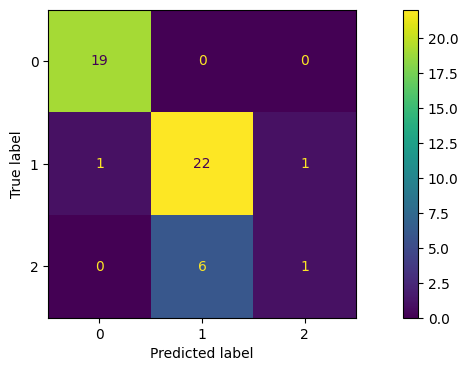

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_holdout, y_holdout)

Accuracy is a problematic metric when classes are imbalanced. 

It easy to achieve high accuracy just by being accurate on the more frequent class (by always predicting it, for example).

# Trading Off Sensitivity vs. Specificity
With our softmax model, we can simpliy obtain the class probabilities.

The default threshold for predicting class 1 in binary classification is when it has >50\% probability. But we can set it higher or lower.

In [8]:
pred_probabilities = model.predict_proba(X_holdout)
print('Predicted probabilities of class 0 from the model:')
print(pred_probabilities[:10,0])

Predicted probabilities of class 0 from the model:
[0.90500627 0.1628024  0.26248388 0.91899931 0.05452794 0.98241773
 0.90444375 0.87543531 0.83226506 0.12415388]


# Receiver Operating Characteristic (ROC)

In binary classification, the Receiver Operating Characteristic (ROC) curve plots the true positive rate and the false positive rate (FPR) as we vary the threshold for labeling a positive example.

\begin{align*}
\text{TPR} = \underset{\text{(recall, sensitivity)}}{\text{true positive rate}} & = \frac{\text{TP}}{\text{positive class}}  = \frac{\text{TP}}{\text{TP} + \text{FN}} \\
\text{FPR} = 1-\underset{\text{(true negative rate)}}{\text{specificity}} & = 1 - \frac{\text{TN}}{\text{negative class}} = \frac{\text{FP}}{\text{TP} + \text{FP}} \\
\end{align*}

Below, the ROC curve measures the TPR and FPR as we vary $t$.

In [9]:
from sklearn.metrics import roc_curve

class2_scores = pred_probabilities[:,2] # we take class 2 as the "positive" class
# create labels where class 2 is the "positive" class
class2_y = np.zeros(y_holdout.shape)
class2_y[y_holdout==2] = 1
print('First class 2 scores: ', class2_scores[:4])
fpr, tpr, thresholds = roc_curve(class2_y, class2_scores)

First class 2 scores:  [0.02495207 0.15064683 0.17470687 0.00545101]


In [10]:
print(thresholds)
print(fpr)
print(tpr)

[       inf 0.60893169 0.45622411 0.43695269 0.43692903 0.4081611
 0.40436622 0.37732754 0.36449565 0.33312532 0.21568224 0.18095494
 0.17470687 0.15943628 0.0172912  0.01616985 0.00845692 0.00787454
 0.00237888]
[0.         0.         0.04651163 0.04651163 0.06976744 0.06976744
 0.09302326 0.09302326 0.13953488 0.13953488 0.27906977 0.30232558
 0.37209302 0.37209302 0.72093023 0.76744186 0.8372093  0.88372093
 1.        ]
[0.         0.14285714 0.14285714 0.28571429 0.28571429 0.42857143
 0.42857143 0.57142857 0.57142857 0.71428571 0.71428571 0.85714286
 0.85714286 1.         1.         1.         1.         1.
 1.        ]


We can visualize the TPR vs. the FPR at various thresholds.

Text(0.5, 1.0, 'Receiver operating characteristic')

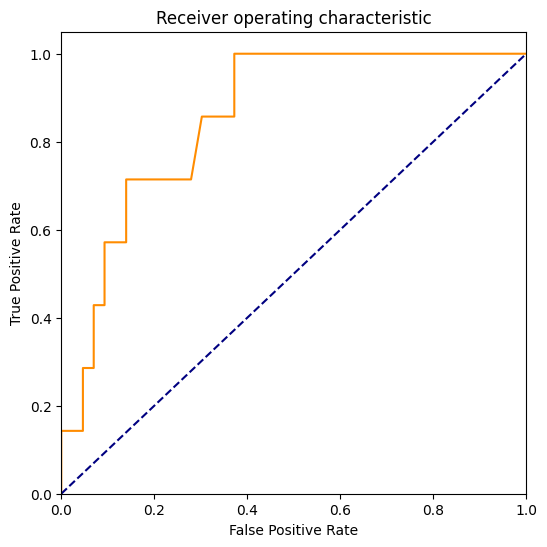

In [11]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')

# Area Under the Curve

We may compute the AUC of the above ROC curve as follows.

In [12]:
from sklearn.metrics import auc
print('AUC-ROC: %.4f' % auc(fpr, tpr))

AUC-ROC: 0.8555


# Multi-Class Generalizations
In multi-class settings, we average binary metrics in various ways:
* `macro`: We average binary one-vs-all metrics for each class.
$$\text{precision}_\text{macro} = \frac{1}{K} \sum_{k=1}^K \frac{\text{TP}_k}{\text{TP}_k + \text{FP}_k}$$
* `micro`: We average binary metrics across classes.
$$\text{precision}_\text{micro} = \frac{\sum_{k=1}^K \text{TP}_k}{\sum_{k=1}^K (\text{TP}_k + \text{FP}_k)}$$

See the `scikit-learn` [guide](https://scikit-learn.org/stable/modules/model_evaluation.html) for more on model evaluation.

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_holdout, y_pred, target_names=['Setosa', 'Versicolor', 'Virginica']))

              precision    recall  f1-score   support

      Setosa       0.95      1.00      0.97        19
  Versicolor       0.79      0.92      0.85        24
   Virginica       0.50      0.14      0.22         7

    accuracy                           0.84        50
   macro avg       0.75      0.69      0.68        50
weighted avg       0.81      0.84      0.81        50

